# FARHANKHAN F. PATHAN
# ROLL NO. 61
# CSAI D-3

**Asssignment 6**
6.	Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression modeling c. Multiple Regression analysis d. Also compare the results of the above analysis for the two data sets. Dataset link:

Importing Dependencies

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

Reading CSV

In [ ]:
df = pd.read_csv("diabetes.csv")

In [ ]:
print("Diabetes Dataset Shape:", df.shape)

Diabetes Dataset Shape: (768, 9)


In [ ]:
print(df.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


CHECKPOINT 1: Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

In [ ]:
univariate = pd.DataFrame({
    "Frequency": df.count(),
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Variance": df.var(),
    "Std Dev": df.std(),
    "Skewness": df.skew(),
    "Kurtosis": df.kurt()
})

print(univariate)

                          Frequency        Mean    Median    Mode  \
Pregnancies                     768    3.845052    3.0000   1.000   
Glucose                         768  120.894531  117.0000  99.000   
BloodPressure                   768   69.105469   72.0000  70.000   
SkinThickness                   768   20.536458   23.0000   0.000   
Insulin                         768   79.799479   30.5000   0.000   
BMI                             768   31.992578   32.0000  32.000   
DiabetesPedigreeFunction        768    0.471876    0.3725   0.254   
Age                             768   33.240885   29.0000  22.000   
Outcome                         768    0.348958    0.0000   0.000   

                              Variance     Std Dev  Skewness  Kurtosis  
Pregnancies                  11.354056    3.369578  0.901674  0.159220  
Glucose                    1022.248314   31.972618  0.173754  0.640780  
BloodPressure               374.647271   19.355807 -1.843608  5.180157  
SkinThickness    

CHECKPOINT 2: Bivariate analysis: Linear and logistic regression modeling

1. Linear Regression

For Pregnancies and Age

Finding Correlation for better modelling

In [ ]:
corr = df["Pregnancies"].corr(df["Glucose"])
print("Correlation (r):", corr)

Correlation (r): 0.12945867149927245


In [ ]:
corr = df["Pregnancies"].corr(df["Age"])
print("Correlation (r):", corr)


Correlation (r): 0.5443412284023394


In [ ]:
  X = df[["Pregnancies"]]
  y = df["Age"]

  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

  model = LinearRegression()

  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  print("Coefficient (slope):", model.coef_)
  print("Intercept:", model.intercept_)

  print("MSE:", mean_squared_error(y_test, y_pred))
  print("R2 Score:", r2_score(y_test, y_pred))


Coefficient (slope): [1.95153645]
Intercept: 25.80256156735291
MSE: 100.51229439425396
R2 Score: 0.2929856197397712


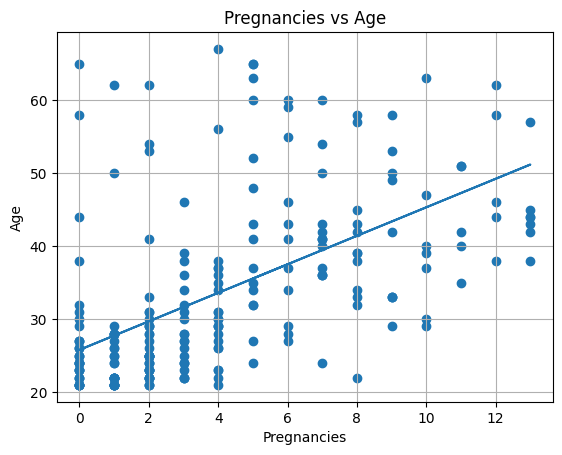

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Pregnancies vs Age")
plt.xlabel("Pregnancies")
plt.ylabel("Age")
plt.grid()
plt.show()

For Glucose and BMI

In [ ]:
corr = df["Glucose"].corr(df["BMI"])
print("Correlation (r):", corr)

Correlation (r): 0.22107106945898294


In [ ]:
  X = df[["Glucose"]]
  y = df["BMI"]

  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

  model = LinearRegression()

  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  print("Coefficient (slope):", model.coef_)
  print("Intercept:", model.intercept_)

  print("MSE:", mean_squared_error(y_test, y_pred))
  print("R2 Score:", r2_score(y_test, y_pred))


Coefficient (slope): [0.04804019]
Intercept: 26.169988281206813
MSE: 67.16075579257195
R2 Score: 0.06071392018823474


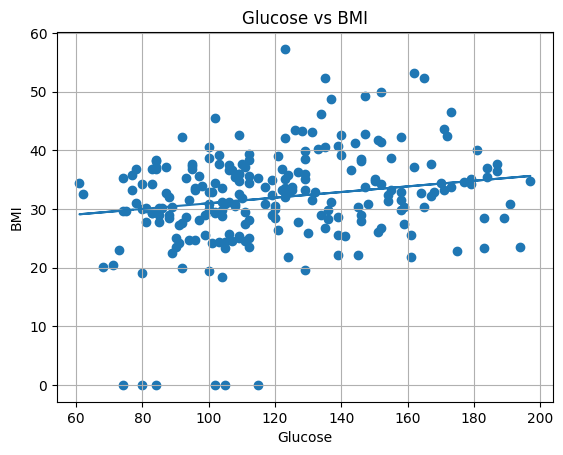

In [ ]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.title("Glucose vs BMI")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.grid(True)
plt.show()


2. Logistic Regression

In [ ]:
  X = df[["Glucose"]]
  y = df["Outcome"]

  X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

  model = LogisticRegression()

  model.fit(X_train, y_train)

  y_pred = model.predict(X_test)

  print("Coefficient:", model.coef_)
  print("Intercept:", model.intercept_)

  print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Coefficient: [[0.04033676]]
Intercept: [-5.6523997]

Confusion Matrix:
 [[128  23]
 [ 41  39]]


CHECKPOINT 3: Multiple Regression analysis

In [ ]:
X = df[["Pregnancies", "Glucose", "BloodPressure"]]
y = df["BMI"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nCoefficients:")

coeff_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_table)
print("\nIntercept:", model.intercept_)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



Coefficients:
         Feature  Coefficient
0    Pregnancies    -0.071614
1        Glucose     0.040317
2  BloodPressure     0.092979

Intercept: 20.890899414645247
MSE: 60.25177614509201
R2 Score: 0.15734041481291927


Visualise for Multiple Regression

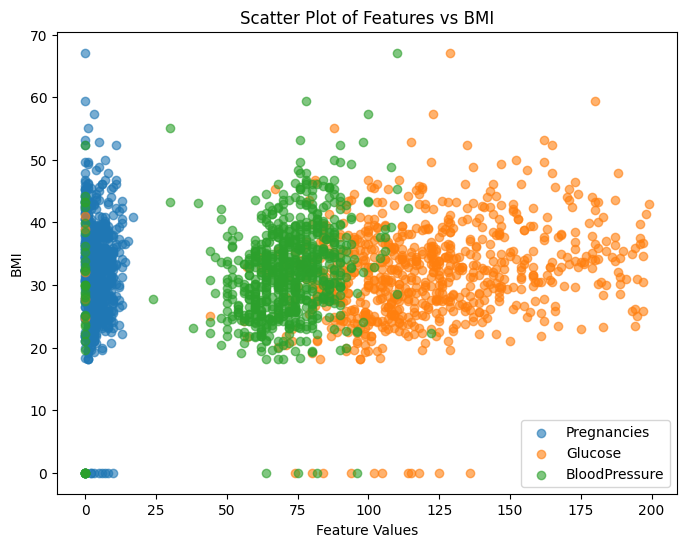

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(df["Pregnancies"], df["BMI"], label="Pregnancies", alpha=0.6)
plt.scatter(df["Glucose"], df["BMI"], label="Glucose", alpha=0.6)
plt.scatter(df["BloodPressure"], df["BMI"], label="BloodPressure", alpha=0.6)

plt.xlabel("Feature Values")
plt.ylabel("BMI")
plt.title("Scatter Plot of Features vs BMI")
plt.legend()
plt.show()

"Age", "BMI", "BloodPressure" V/S DiabetesPedigreeFunction

In [ ]:
X = df[["Age", "BMI", "BloodPressure"]]
y = df["DiabetesPedigreeFunction"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=42 )

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nCoefficients:")

coeff_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coeff_table)
print("\nIntercept:", model.intercept_)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))



Coefficients:
         Feature  Coefficient
0            Age     0.001015
1            BMI     0.006339
2  BloodPressure    -0.000143

Intercept: 0.24357844260541234
MSE: 0.0911036428916671
R2 Score: 0.019735895191821173


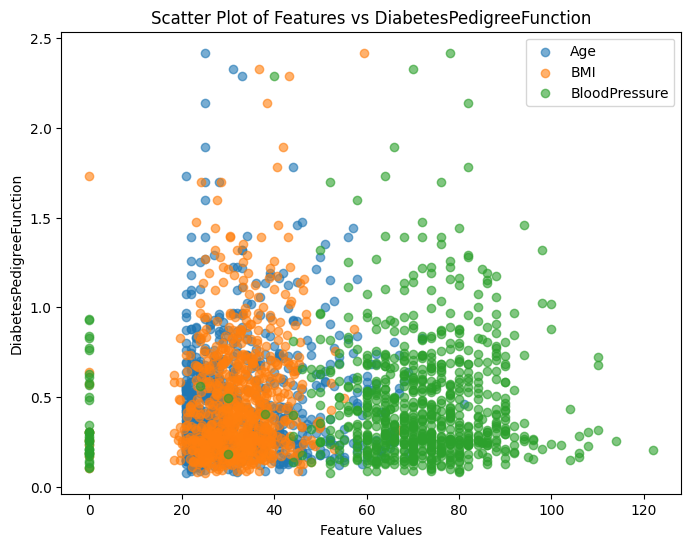

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(df["Age"], df["DiabetesPedigreeFunction"], label="Age", alpha=0.6)
plt.scatter(df["BMI"], df["DiabetesPedigreeFunction"], label="BMI", alpha=0.6)
plt.scatter(df["BloodPressure"], df["DiabetesPedigreeFunction"], label="BloodPressure", alpha=0.6)

plt.xlabel("Feature Values")
plt.ylabel("DiabetesPedigreeFunction")
plt.title("Scatter Plot of Features vs DiabetesPedigreeFunction")
plt.legend()
plt.show()